In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df = sns.load_dataset('titanic')

In [128]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [130]:
df.shape

(891, 15)

In [132]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [134]:
df.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [136]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [138]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [140]:
df['age'] = df['age'].fillna(df['age'].median())

In [142]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

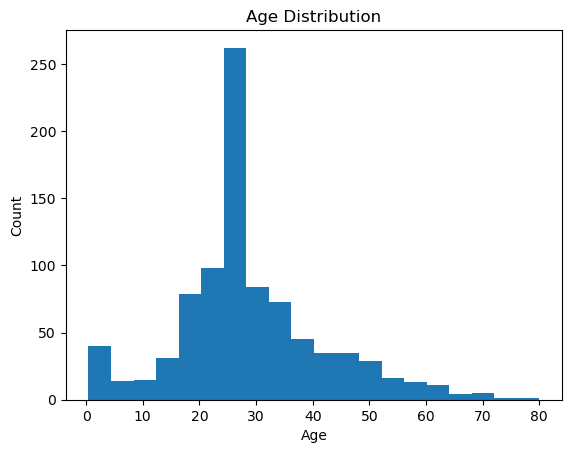

In [144]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [88]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [90]:
df.drop_duplicates(inplace=True)

In [92]:
df['sex'] = df['sex'].map({'male':0, 'female':1})

In [94]:
df['embarked'] = df['embarked'].map({'S':0, 'C':1, 'Q':2})

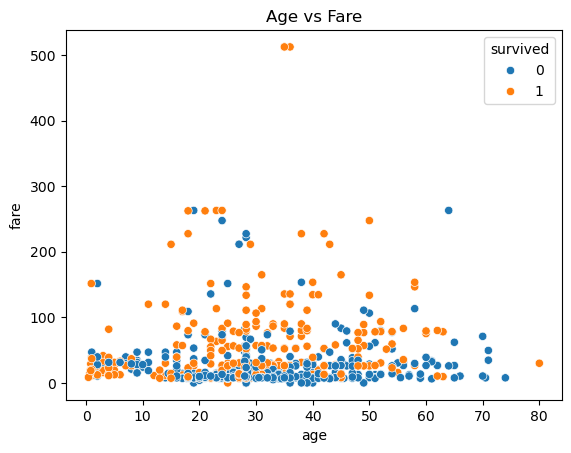

In [98]:
sns.scatterplot(
    x='age',
    y='fare',
    hue='survived',
    data=df
)

plt.title("Age vs Fare")

plt.show()

In [100]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [146]:

df.columns = df.columns.str.strip()
print(df.columns.tolist())


df['age'] = df['age'].fillna(df['age'].median())

df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)


df.drop('deck', axis=1, inplace=True)


df.drop_duplicates(inplace=True)


print(df.isnull().sum())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


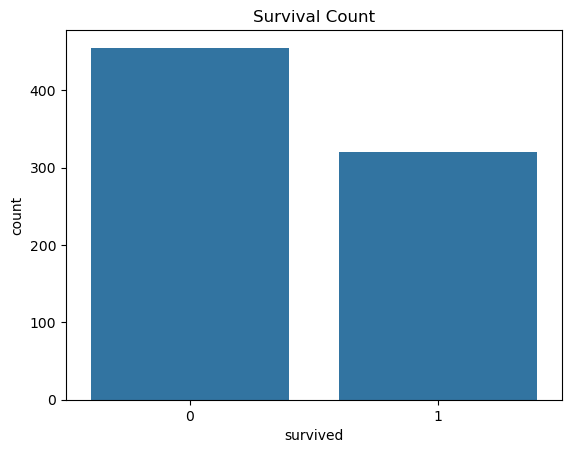

In [148]:
sns.countplot(x='survived', data=df)

plt.title("Survival Count")

plt.show()

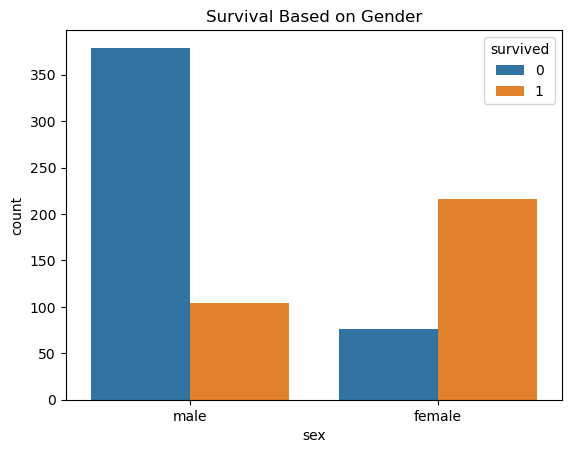

In [149]:
sns.countplot(
    x='sex',
    hue='survived',
    data=df
)

plt.title("Survival Based on Gender")

plt.show()

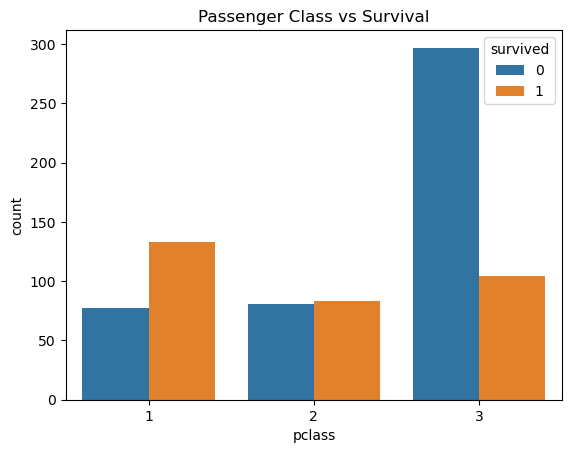

In [150]:
sns.countplot(
    x='pclass',
    hue='survived',
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

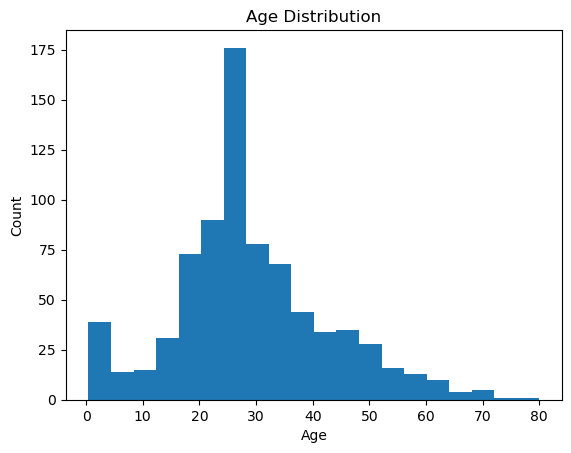

In [152]:
plt.hist(df['age'], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

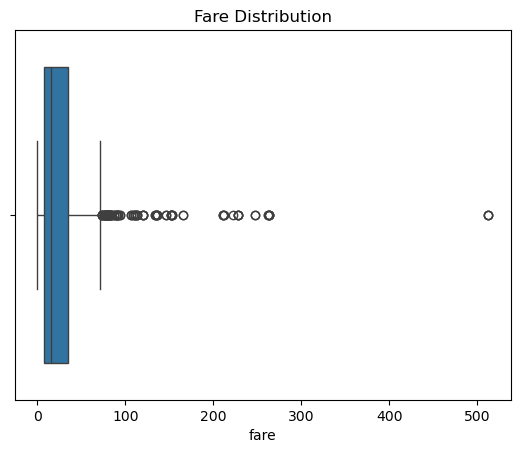

In [154]:
sns.boxplot(x=df['fare'])

plt.title("Fare Distribution")

plt.show()

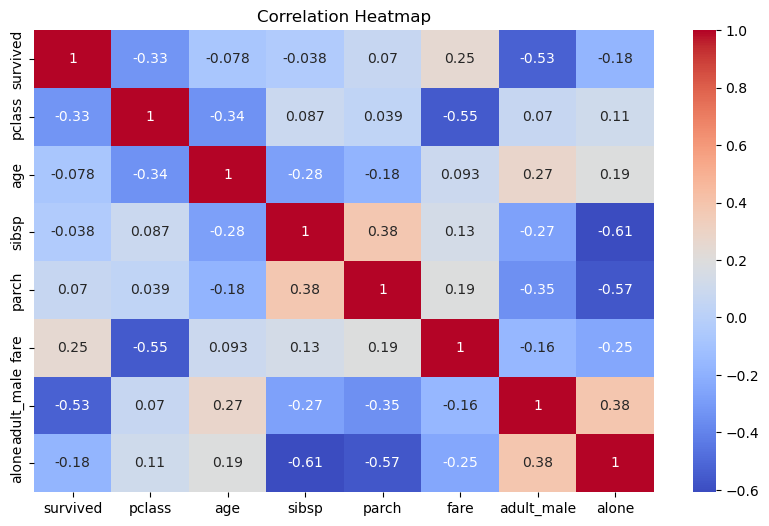

In [155]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

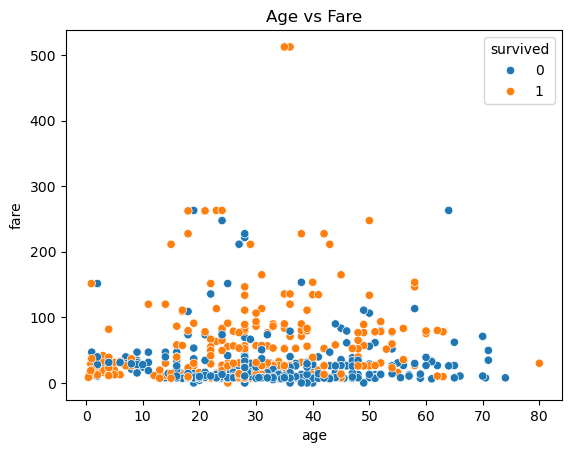

In [160]:
sns.scatterplot(
    x='age',
    y='fare',
    hue='survived',
    data=df
)

plt.title("Age vs Fare")

plt.show()

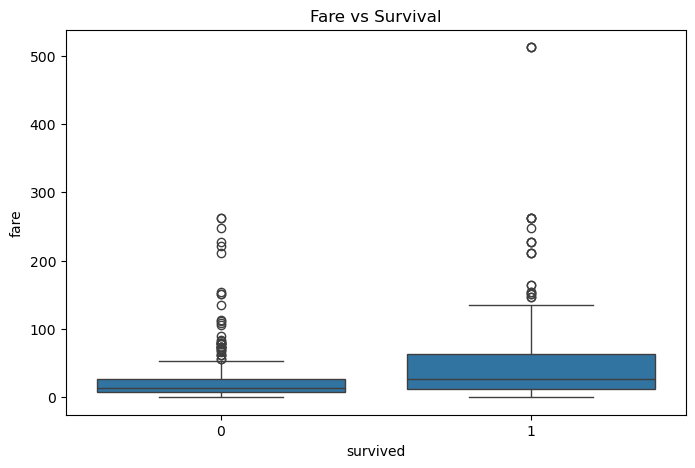

In [162]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='survived',
    y='fare',
    data=df
)

plt.title("Fare vs Survival")

plt.show()

In [164]:
df['family_size'] = df['sibsp'] + df['parch']

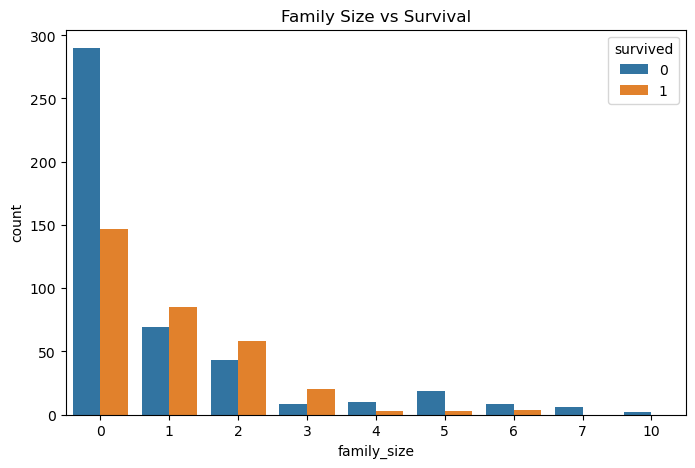

In [166]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='family_size',
    hue='survived',
    data=df
)

plt.title("Family Size vs Survival")

plt.show()

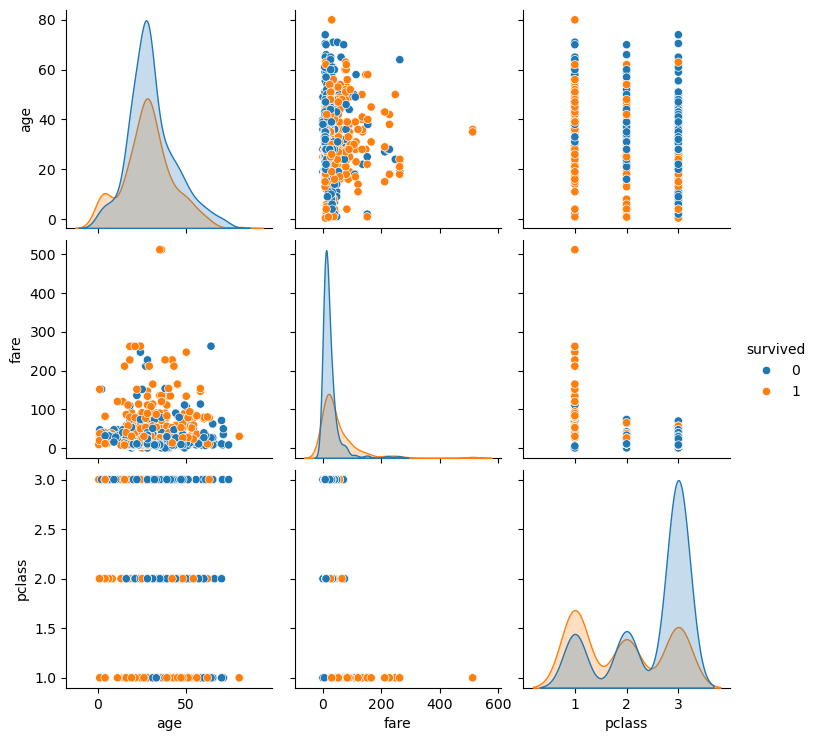

In [169]:
sns.pairplot(
    df[['age', 'fare', 'pclass', 'survived']],
    hue='survived'
)

plt.show()

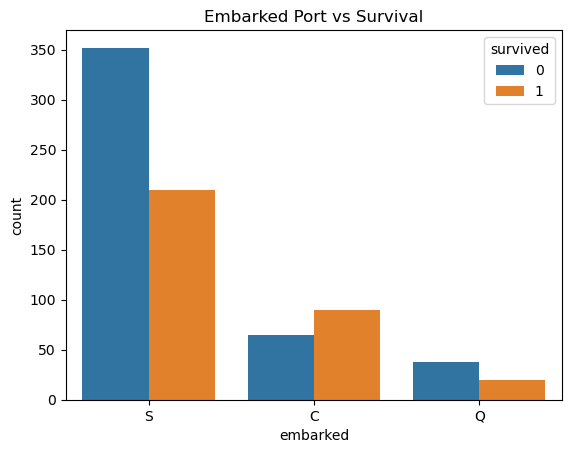

In [170]:
sns.countplot(
    x='embarked',
    hue='survived',
    data=df
)

plt.title("Embarked Port vs Survival")

plt.show()

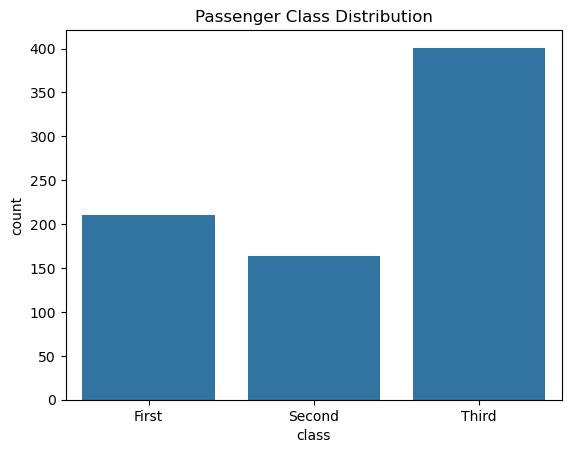

In [171]:
sns.countplot(
    x='class',
    data=df
)

plt.title("Passenger Class Distribution")

plt.show()